In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../')
from proof_of_concept.models.staged import STAGED
from proof_of_concept.utils.graph_constructor import GraphConstructor
from proof_of_concept.utils.simulated_data_processing import retrieve_simulated_data, retrieve_real_data

from proof_of_concept.tests.test_graph_constructor import create_square_grid_data as create_test_data
from proof_of_concept.utils.data_factory import create_oscillatory_dynamics_data
from proof_of_concept.utils.visualization import visualize_attention_graph, visualize_graph

In [2]:
data = retrieve_real_data(data_dir='../data/real')
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([10, 100, 428])
cell_positions: torch.Size([10, 100, 2])
genes: length 428
cell_type_assignments: torch.Size([100])
prior_grns: length 8
receptor_gene_pairs: length 3
ligand_receptor_pairs: length 3
n_time_points: 10
n_cells: 100
n_genes: 428


In [ ]:
import pickle
cell_type = 0

with open(f'../inference_results/real/inference_celltype_{cell_type}_ode_new.pkl', 'rb') as f:
    infered_results = pickle.load(f)

In [46]:
predictions = infered_results['predictions'] +1.5  # shape: (n_pred_time_points, n_cells, n_genes)
time_points = infered_results['time_points']
genes = infered_results['genes']
n_cells = predictions.shape[1]

# Plot gene expression for all genes in all cells over time
gene_expression = data['gene_expression']  # shape: (n_time_points, n_cells, n_genes)
n_time_points, n_cells, n_genes = gene_expression.shape

In [47]:
import os


output_dir = f'../inference_results/plots/cell_type_{cell_type}'
os.makedirs(output_dir, exist_ok=True)


In [48]:

predictions = infered_results['predictions'] +.5 
time_points = infered_results['time_points']

mean_expr = np.mean(predictions, axis=1)  # Average across cells
gene_variance = np.var(mean_expr, axis=0)
top_genes = np.argsort(gene_variance)[-4:]  # Top 4 most variable genes

# Compute mean and std across cells for true gene expression
true_mean_expr = gene_expression.mean(dim=1).cpu().numpy()  # shape: (n_time_points, n_genes)
true_std_expr = gene_expression.std(dim=1).cpu().numpy()


In [49]:
# Create color mapping for cell types
unique_cell_types = np.unique(cell_type)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_cell_types)))
cell_type_colors = dict(zip(unique_cell_types, colors))

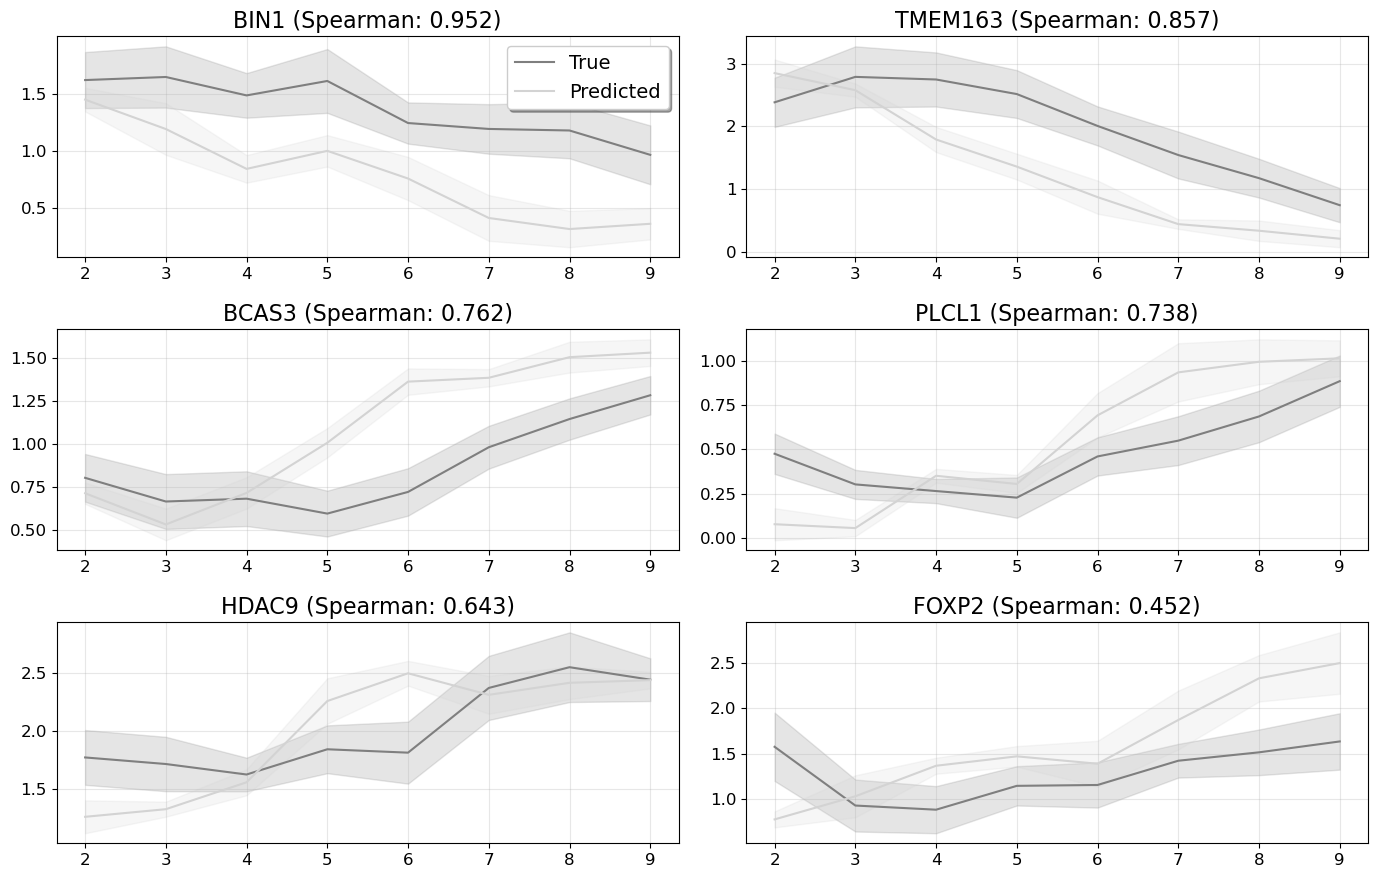

In [50]:
# Overlay true and predicted gene expression trajectories for top n_genes varying genes
n_genes = 6
top_variable_genes = np.argsort(gene_variance)[-n_genes:]  # Top n_genes most variable genes

# Calculate Spearman correlation for each gene and sort by correlation
from scipy.stats import spearmanr
gene_correlations = []
for gene_idx in top_variable_genes:
    correlation, _ = spearmanr(true_mean_expr[:len(time_points), gene_idx], mean_expr[:, gene_idx])
    gene_correlations.append((gene_idx, correlation))

# Sort genes by Spearman correlation (best to worst)
gene_correlations.sort(key=lambda x: x[1], reverse=True)
top_n_genes = [gene_idx for gene_idx, _ in gene_correlations]

# Define colors based on cell_type
color_map = {
    0: ('tab:blue', 'lightblue'),
    1: ('tab:red', 'lightcoral'),
    2: ('tab:green', 'lightgreen'),
    3: ('tab:orange', 'moccasin'),
    4: ('tab:purple', 'plum'),
    5: ('tab:brown', 'tan'),
    6: ('tab:pink', 'lightpink'),
    7: ('tab:gray', 'lightgray'),
    8: ('tab:olive', 'darkkhaki')
}

if cell_type in color_map:
    true_color, pred_color = color_map[cell_type]
else:
    true_color = 'tab:blue'
    pred_color = 'tab:orange'

# Calculate the maximum expression level across all genes for consistent y-axis scaling
max_expression = 0
for gene_idx in top_n_genes:
    # Maximum from true values (with confidence intervals)
    true_upper = true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx]
    max_true = np.max(true_upper)
    
    # Maximum from predicted values (with confidence intervals)
    pred_upper = mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1)
    max_pred = np.max(pred_upper)
    
    # Update global maximum
    max_expression = max(max_expression, max_true, max_pred)

# Set font sizes for all text elements
plt.rcParams.update({
    'font.size': 14,           # Default font size
    'axes.titlesize': 16,      # Title font size
    'axes.labelsize': 14,      # Axis label font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 14      # Legend font size
})

n_rows = n_genes // 2 + n_genes % 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))
axes = axes.flatten()

# Create a flag to add legend only once
legend_added = False

for i, gene_idx in enumerate(top_n_genes):
    ax = axes[i]
    # True values (aligned to prediction time points)
    line1 = ax.plot(
        time_points,
        true_mean_expr[:len(time_points), gene_idx],
        color=true_color,
        label='True'
    )[0]
    ax.fill_between(
        time_points,
        true_mean_expr[:len(time_points), gene_idx] - true_std_expr[:len(time_points), gene_idx],
        true_mean_expr[:len(time_points), gene_idx] + true_std_expr[:len(time_points), gene_idx],
        color=true_color,
        alpha=0.2
    )
    # Predicted values
    line2 = ax.plot(
        time_points,
        mean_expr[:, gene_idx],
        color=pred_color,
        label='Predicted'
    )[0]
    ax.fill_between(
        time_points,
        mean_expr[:, gene_idx] - np.std(predictions[:, :, gene_idx], axis=1),
        mean_expr[:, gene_idx] + np.std(predictions[:, :, gene_idx], axis=1),
        color=pred_color,
        alpha=0.2
    )
    
    gene_name = genes[gene_idx] if genes else f'Gene_{gene_idx}'
    
    # Calculate Spearman correlation between true and predicted values
    correlation = gene_correlations[i][1]  # Use pre-calculated correlation
    
    ax.set_title(f'{gene_name} (Spearman: {correlation:.3f})')
    ax.grid(True, alpha=0.3)
    
    # Add single legend to the first subplot (top-left corner)
    if i == 0:
        ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
    
    # Set y-axis limits using the calculated maximum across all plots
    # ax.set_ylim(0, max_expression * 1.05)  # Add 5% padding for better visualization

# Hide unused subplots if any
for i in range(len(top_n_genes), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'gene_trajectories_overlay_top{n_genes}.png'), dpi=300, bbox_inches='tight')
plt.show()